# Linking SDG&E utility data with Zillow points and multifamily parcels
This notebook will take Zillow points and multifamily pacels linking to the nearest SDG&E feeder line.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import box
from shapely.geometry import MultiLineString
import matplotlib.pyplot as plt
import glob
import os
import folium

## Load SDGE line data

In [2]:
# read in data
sdge_feederlines = gpd.read_file("../../../../capstone/electrigrid/data/utilities/sandiego_grid/gen_cap_lines_sdge.geojson")

In [3]:
sdge_feederlines.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [4]:
# view the top of the dataframe
sdge_feederlines.head()

,LINE_SEGMENT_NUMBER,CIRCUIT_NAME,SUBID,ICAWOF_UNIGENERATION,ICAWOF_UNILOAD,ICAWNOF_UNIGENERATION,ICAWNOF_UNILOAD,OBJECTID,VOLTAGE,ICAWOF_PVGENERATION,OHUG,LABELTEXT,ICAWNOF_PVGENERATION,LABELTEXT_ICA,RESTRICTED,ICAWOF_UNIGENERATION_LC,ICAWOF_UNILOAD_LC,ICAWNOF_UNIGENERATION_LC,geometry
0,1,221,SANTA YSABEL,0.0,0.2,0.0,0.2,32929650,12,0.1,OH,None,0.1,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"LINESTRING (-116.43681 32.97732, -116.43681 32..."
1,21,211,WARNERS,0.0,0.0,0.0,0.0,32789112,12,0.1,OH,None,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage,"LINESTRING (-116.52521 33.22100, -116.52521 33..."
2,22,211,WARNERS,0.0,0.0,0.0,0.0,32783141,12,0.1,OH,None,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage,"LINESTRING (-116.52522 33.21894, -116.52522 33..."
3,24,211,WARNERS,0.0,0.0,0.0,0.0,32784298,12,0.1,OH,None,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage,"LINESTRING (-116.53426 33.21107, -116.53426 33..."
4,25,211,WARNERS,0.0,0.0,0.0,0.0,32784301,12,0.1,OH,None,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage,"LINESTRING (-116.53751 33.21427, -116.53730 33..."


## Load in building and parcel data

In [ ]:
# read in multifamily data
sdge_multifamily = gpd.read_file("../../../../capstone/electrigrid/data/sdcounty_building_zillow_merge/multi_summed_units_sd.geojson")

In [8]:
sdge_multifamily.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

The entirety of the Zillow data takes approximately 15 muinutes to run. This data is clipped to the SDG&E and saved to reduce load time. Code commented out below is to avoid the excessive data loading and make sure the data isn't downloaded again. The final SDG&E single family home data is uploaded to the Capstone electri-grid data folder.  

In [ ]:
# # load in zillow data
# sdge_singlefamily = gpd.read_file("../../../../capstone/electrigrid/data/buildings/final_zillow.gpkg")

In [ ]:
# sdge_singlefamily.crs

<Projected CRS: EPSG:26910>
Name: NAD83 / UTM zone 10N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: North America - between 126°W and 120°W - onshore and offshore. Canada - British Columbia; Northwest Territories; Yukon. United States (USA) - California; Oregon; Washington.
- bounds: (-126.0, 30.54, -119.99, 81.8)
Coordinate Operation:
- name: UTM zone 10N
- method: Transverse Mercator
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [ ]:
# sdge_singlefamily = sdge_singlefamily.to_crs("EPSG:4326")

In [10]:
# load in shapefile for extent of SDGE
path = "../../../../capstone/electrigrid/data/utilities/ElectricLoadServingEntities_IOU_POU_-3184854433875766149.geojson"
utility_ter = gpd.read_file(path)

In [11]:
# view data frame
utility_ter.head()

,OBJECTID,Acronym,Utility,AgencyNum,Type,URL,Phone,Address,HIFLD_ID,Sales_GWh_1990,...,Sales_GWh_2019,Sales_GWh_2020,Sales_GWh_2021,Sales_GWh_2022,Sales_GWh_2023,Sales_GWh_2024,Sales_GWh_2025,OnlineName,Audit,geometry
0,1,,PacifiCorp,71026.0,IOU,https://www.pacificorp.com/,(503) 813-5000,"825 NE Multnomah Street, Suite 2000 Portland, ...",14354,736.955156,...,742.775668,762.225388,794.358238,801.710660,774.312862,None,None,None,None,"MULTIPOLYGON Z (((-124.20211 41.74485 0.00000,..."
1,2,,Liberty Utilities,84372.0,IOU,http://www.libertyutilities.com/west/?region=C...,800.782.2506,"933 Eloise Ave South Lake Tahoe, CA 96150",57483,426.373385,...,564.199718,553.802343,559.771745,558.609575,539.033661,None,None,None,None,"POLYGON Z ((-120.08497 39.70865 0.00000, -120...."
2,3,SCE,Southern California Edison,86250.0,IOU,https://www.sce.com/,(818) 302-1212,"2244 Walnut Grove Avenue Rosemead, CA 91770-3714",17609,71016.547845,...,81183.999994,81054.000005,81132.999996,82971.000004,76840.077169,None,None,None,None,"MULTIPOLYGON Z (((-118.60361 33.47801 0.00000,..."
3,4,PG&E,Pacific Gas & Electric Company,71021.0,IOU,https://www.pge.com/,(415) 973-7000,"77 Beale Street San Francisco, CA 94105",14328,70036.326445,...,78389.925613,78518.835139,78438.000003,77887.000005,72932.833237,None,None,None,None,"MULTIPOLYGON Z (((-120.87195 35.21664 0.00000,..."
4,5,SDG&E,San Diego Gas & Electric,80402.0,IOU,https://www.sdge.com/,(619) 696-2000,"P.O. Box 129831 San Diego, CA 92112-9831",16609,14396.900280,...,17681.971922,17444.765817,17444.765817,17867.262050,16982.218070,None,None,None,None,"MULTIPOLYGON Z (((-117.12961 32.62193 0.00000,..."


In [12]:
# filter to only sdge 
shape_sdge = utility_ter[utility_ter['Acronym'] == 'SDG&E'] 

# check the crs
shape_sdge.crs


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
# assert shape_sdge.crs == sdge_singlefamily.crs

# # crop the single family zillow points 
# sdge_singlefamily = gpd.clip(sdge_singlefamily, shape_sdge)

In [ ]:
# sdge_singlefamily.head()

,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,ID,GEOID,p_ID,area,code,geometry
7969765,Single,1947.0,3.0,None,None,O,1.0,117939.0,living,1456.0,8342205,06073021102,h210,SDGE,RR101,POINT (-116.18797 32.61242)
7969764,Single,1958.0,2.0,None,None,None,1.0,44966.0,living,576.0,8342204,06073021102,h210,SDGE,RR101,POINT (-116.18770 32.61266)
8007755,Single,2000.0,1.0,None,None,None,1.0,173672.0,living,2400.0,8401151,06073021102,h210,SDGE,RR101,POINT (-116.18885 32.61269)
7969767,Single,1948.0,2.0,None,None,None,1.0,85328.0,living,1024.0,8342207,06073021102,h210,SDGE,RR101,POINT (-116.18876 32.61287)
7969668,Single,2002.0,2.0,None,None,O,1.0,371922.0,living,2145.0,8342100,06073021102,h210,SDGE,RR101,POINT (-116.19624 32.61295)


In [ ]:
# # save the a geojson file of single family homes as a geojson package
# output_shapefile_path = 'sdge_singlefamily.geojson'

# sdge_singlefamily.to_file(output_shapefile_path)

### Read in the SDG&E single family home

In [19]:
# make sure the data works 
sdge_singlefamily = gpd.read_file("../../../../capstone/electrigrid/data/sdcounty_building_zillow_merge/sdge_singlefamily.geojson")

<Axes: >

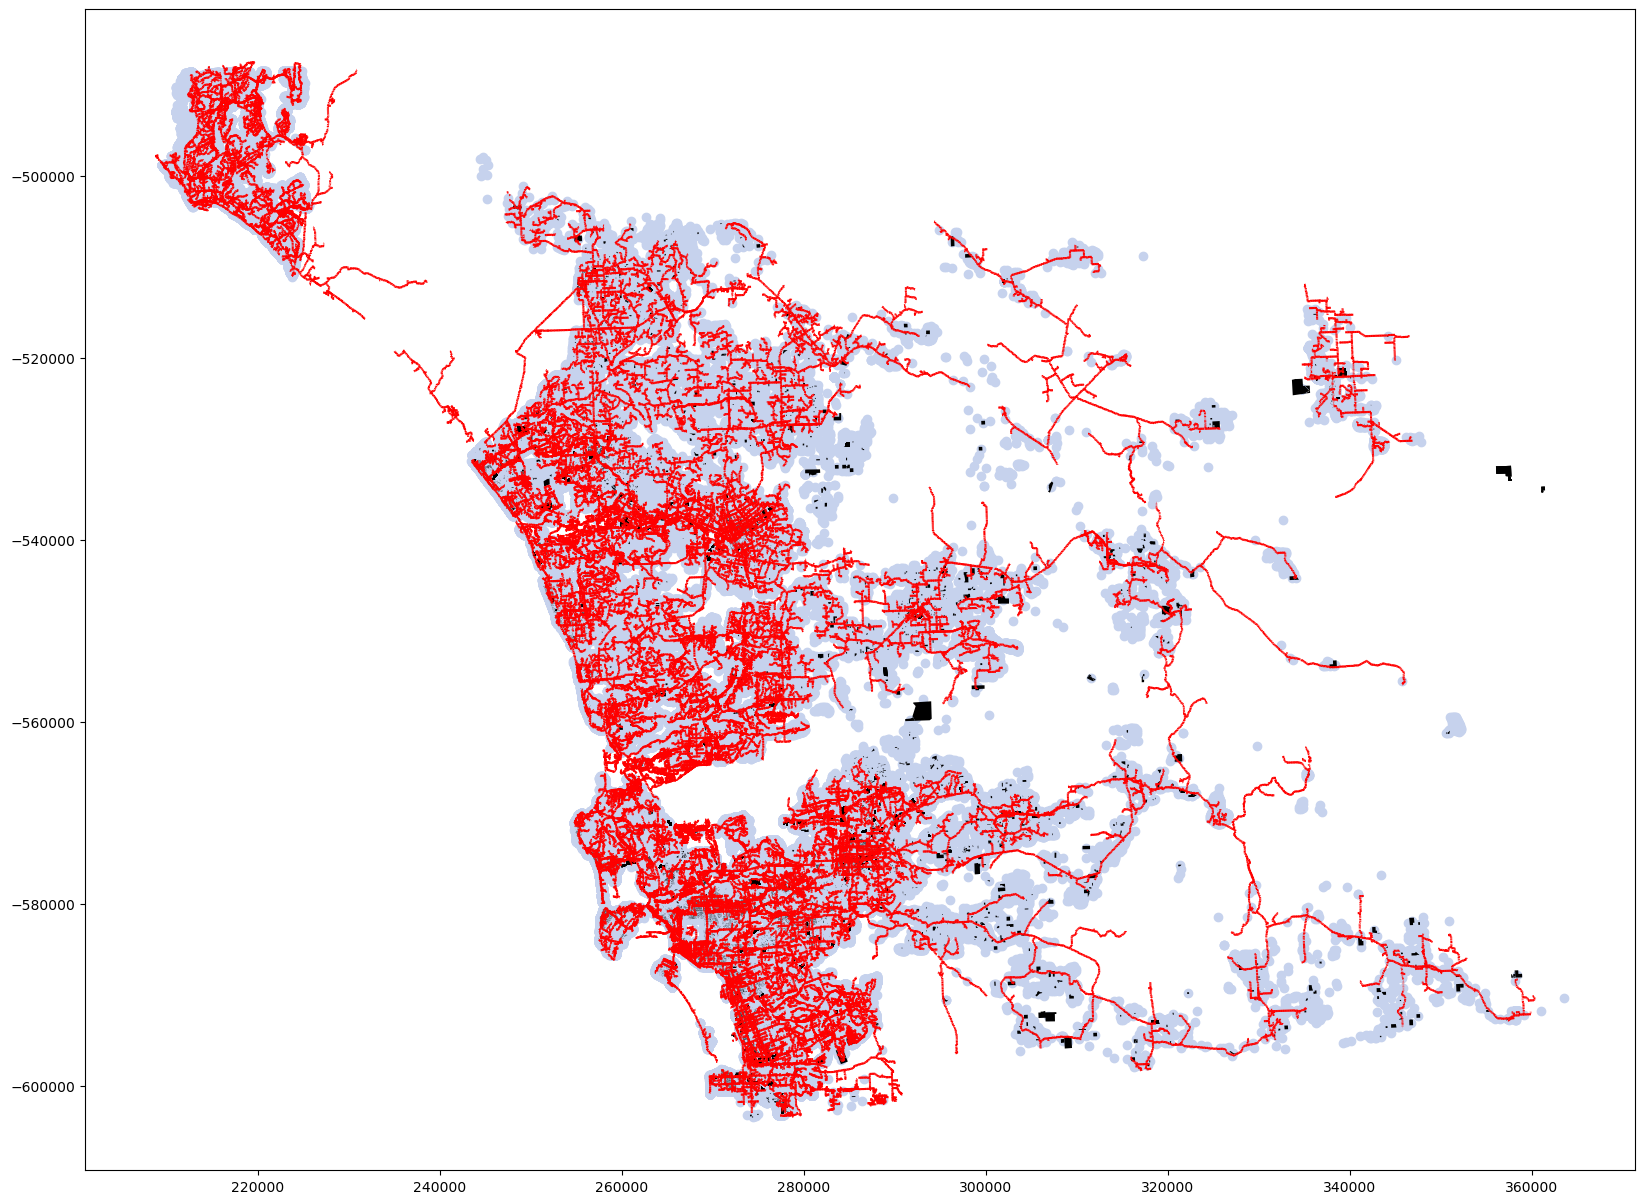

In [32]:
# plot the single family homes, multi-family homes, and electric grid lines 
fig, ax = plt.subplots(figsize=(20, 20))

# ax.axis('off')

sdge_singlefamily.plot(ax=ax, 
                    color='#C6D2ED')

sdge_multifamily.plot(ax=ax, 
                    color='black')

sdge_feederlines.plot(ax=ax, 
                      color='red')

# Link data

Use `sjoin_nearest()` to calculate the nearest line for each home. `sjoin_nearest()` works on projected CRS not geographic so first transform the CRS.

#### Link single family homes

In [24]:
# change the crs to a projected CRS
sdge_feederlines = sdge_feederlines.to_crs("EPSG:3310")
sdge_singlefamily = sdge_singlefamily.to_crs("EPSG:3310")

# index the data
sdge_feederlines.sindex
sdge_singlefamily.sindex

# spatial join
sdge_singlefamily_linked = gpd.sjoin_nearest(sdge_singlefamily, 
                                        sdge_feederlines, 
                                        how="left", 
                                        lsuffix='_left', 
                                        rsuffix='_right',
                                        distance_col='dist_to_line_m')

In [25]:
sdge_singlefamily_linked.head()

,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,...,ICAWOF_PVGENERATION,OHUG,LABELTEXT,ICAWNOF_PVGENERATION,LABELTEXT_ICA,RESTRICTED,ICAWOF_UNIGENERATION_LC,ICAWOF_UNILOAD_LC,ICAWNOF_UNIGENERATION_LC,dist_to_line_m
0,Single,1947.0,3.0,None,None,O,1.0,117939.0,living,1456.0,...,1.0,OH,None,1.0,Up to 1.00,N,ICA_Operation_Flex,Load_Thermal,ICA_Voltage_Delta,244.699737
1,Single,1958.0,2.0,None,None,None,1.0,44966.0,living,576.0,...,1.0,OH,None,1.0,Up to 1.00,N,ICA_Operation_Flex,Load_Thermal,ICA_Voltage_Delta,241.795582
2,Single,2000.0,1.0,None,None,None,1.0,173672.0,living,2400.0,...,1.0,OH,None,1.0,Up to 1.00,N,ICA_Operation_Flex,Load_Thermal,ICA_Voltage_Delta,176.875959
3,Single,1948.0,2.0,None,None,None,1.0,85328.0,living,1024.0,...,1.0,OH,None,1.0,Up to 1.00,N,ICA_Operation_Flex,Load_Thermal,ICA_Voltage_Delta,162.951749
4,Single,2002.0,2.0,None,None,O,1.0,371922.0,living,2145.0,...,0.9,OH,None,0.9,Up to 1.00,N,ICA_Operation_Flex,Load_Thermal,ICA_Voltage_Delta,12.242524


In [26]:
print(sdge_singlefamily_linked['dist_to_line_m'].min())
print(sdge_singlefamily_linked['dist_to_line_m'].max())

6.056636401165891e-05
8100.25594916158


#### Link multi-family homes

In [28]:
# change the crs to a projected CRS
sdge_feederlines = sdge_feederlines.to_crs("EPSG:3310")
sdge_multifamily = sdge_multifamily.to_crs("EPSG:3310")

# index the data
sdge_feederlines.sindex
sdge_multifamily.sindex

# spatial join
sdge_multifamily_linked = gpd.sjoin_nearest(sdge_multifamily, 
                                        sdge_feederlines, 
                                        how="left", 
                                        lsuffix='_left', 
                                        rsuffix='_right',
                                        distance_col='dist_to_line_m')

In [29]:
sdge_multifamily_linked.head()

,PARNO,County,ADDRESS,CITY,ZIP,Shape_Length,Shape_Area,unit,unit_right,geometry,...,ICAWOF_PVGENERATION,OHUG,LABELTEXT,ICAWNOF_PVGENERATION,LABELTEXT_ICA,RESTRICTED,ICAWOF_UNIGENERATION_LC,ICAWOF_UNILOAD_LC,ICAWNOF_UNIGENERATION_LC,dist_to_line_m
0,4241720700,San Diego,None,None,None,98.936758,434.984710,3.0,NaN,MULTIPOLYGON Z (((259296.188 -575671.743 0.000...,...,2.2,UG,None,6.3,1.50-2.00,N,ICA_Operation_Flex,Load_Thermal,ICA_Voltage,35.666557
1,4241721300,San Diego,None,None,None,76.116160,347.815384,2.0,NaN,MULTIPOLYGON Z (((259352.488 -575701.332 0.000...,...,2.2,UG,None,6.3,1.50-2.00,N,ICA_Operation_Flex,Load_Thermal,ICA_Voltage,0.000000
2,4241722000,San Diego,None,None,None,106.557535,579.922629,3.0,NaN,MULTIPOLYGON Z (((259249.984 -575731.108 0.000...,...,2.2,OH,None,2.7,1.50-2.00,N,ICA_Operation_Flex,Load_Thermal,ICA_Thermal,72.202183
3,4236921300,San Diego,None,None,None,69.352091,238.641330,2.0,5.0,MULTIPOLYGON Z (((257845.932 -579051.223 0.000...,...,1.9,UG,None,3.6,1.50-2.00,N,ICA_Operation_Flex,Load_Thermal,ICA_Voltage,19.383137
4,4236220200,San Diego,None,None,None,67.240870,224.046738,3.0,6.0,MULTIPOLYGON Z (((257730.196 -577905.775 0.000...,...,1.9,OH,None,4.8,1.50-2.00,N,ICA_Operation_Flex,Load_Thermal,ICA_Voltage,14.336659


In [31]:
print(sdge_multifamily_linked['dist_to_line_m'].min())
print(sdge_multifamily_linked['dist_to_line_m'].max())

0.0
15281.47694852102


Investigate where the homes are having extremely large distances to the feeder lines that they're linked with.

In [37]:
sdge_multifamily_linked[sdge_multifamily_linked['dist_to_line_m'] >= 10000]

# max_geom = sdge_multifamily_linked['dist_to_line_m'].max().geometry()

,PARNO,County,ADDRESS,CITY,ZIP,Shape_Length,Shape_Area,unit,unit_right,geometry,...,ICAWOF_PVGENERATION,OHUG,LABELTEXT,ICAWNOF_PVGENERATION,LABELTEXT_ICA,RESTRICTED,ICAWOF_UNIGENERATION_LC,ICAWOF_UNILOAD_LC,ICAWNOF_UNIGENERATION_LC,dist_to_line_m
1284,7725301101,San Diego,None,None,None,1398.478277,78002.356886,54.0,86.0,MULTIPOLYGON Z (((357645.607 -533288.668 0.000...,...,0.2,OH,None,0.3,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,11323.137535
1284,7725301101,San Diego,None,None,None,1398.478277,78002.356886,54.0,86.0,MULTIPOLYGON Z (((357645.607 -533288.668 0.000...,...,0.2,OH,None,0.3,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,11323.137535
1285,7725301104,San Diego,None,None,None,1398.478277,78002.356886,54.0,86.0,MULTIPOLYGON Z (((357645.607 -533288.668 0.000...,...,0.2,OH,None,0.3,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,11323.137535
1285,7725301104,San Diego,None,None,None,1398.478277,78002.356886,54.0,86.0,MULTIPOLYGON Z (((357645.607 -533288.668 0.000...,...,0.2,OH,None,0.3,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,11323.137535
1286,7725301107,San Diego,None,None,None,1398.478277,78002.356886,54.0,86.0,MULTIPOLYGON Z (((357645.607 -533288.668 0.000...,...,0.2,OH,None,0.3,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,11323.137535
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68391,7725301123,San Diego,None,None,None,1398.478277,78002.356886,54.0,86.0,MULTIPOLYGON Z (((357645.607 -533288.668 0.000...,...,0.2,OH,None,0.3,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,11323.137535
68660,7725301125,San Diego,None,None,None,1398.478277,78002.356886,54.0,86.0,MULTIPOLYGON Z (((357645.607 -533288.668 0.000...,...,0.2,OH,None,0.3,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,11323.137535
68660,7725301125,San Diego,None,None,None,1398.478277,78002.356886,54.0,86.0,MULTIPOLYGON Z (((357645.607 -533288.668 0.000...,...,0.2,OH,None,0.3,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,11323.137535
68661,7725301126,San Diego,None,None,None,1398.478277,78002.356886,54.0,86.0,MULTIPOLYGON Z (((357645.607 -533288.668 0.000...,...,0.2,OH,None,0.3,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,11323.137535


# Create a bbox to investigate homes with long distances to feederlines

Some of the distances to the feeder lines is longer than it feels like it should. Investigate where this is the case to see if they are actually that far from the feeder lines or if theres an error with the way that nearest is being calculated. 